In [1]:
#author: "Tarvin"
#date: "2026-03-29"

In [11]:
install.packages(('janitor'))
library(tidyverse)
library(lubridate)
library(forecast)
library(janitor)

also installing the dependency ‘snakecase’





The downloaded binary packages are in
	/var/folders/6n/clr3c9_d5fl3fbpcsrmvbd5m0000gn/T//RtmpwRaYk5/downloaded_packages



Attaching package: ‘janitor’


The following objects are masked from ‘package:stats’:

    chisq.test, fisher.test




In [12]:
employment <- read_csv("employment1.csv")
gdp <- read_csv("gdpindustry.csv")
unemp <- read_csv("unemployment_rate.csv")
head(employment)
head(gdp)
head(unemp)

Rows: 28 Columns: 349
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr   (1): North American Industry Classification System (NAICS)
num (348): January 1997, February 1997, March 1997, April 1997, May 1997, Ju...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 26 Columns: 349
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr   (1): North American Industry Classification System (NAICS)
num (348): January 1997, February 1997, March 1997, April 1997, May 1997, Ju...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 9 Columns: 349
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr   (1): Labour force characteristics
num (34

North American Industry Classification System (NAICS),January 1997,February 1997,March 1997,April 1997,May 1997,June 1997,July 1997,August 1997,September 1997,⋯,March 2025,April 2025,May 2025,June 2025,July 2025,August 2025,September 2025,October 2025,November 2025,December 2025
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
"Total, all industries",13147.7,13215.3,13289.6,13355.9,13732.9,14040.7,14117.3,14172.5,13923.8,⋯,20758.0,20873.8,21191.2,21449.7,21206.7,21086.3,21039.4,21125.7,21117.8,21056.4
Goods-producing sector,3321.3,3332.9,3358.6,3402.4,3571.9,3721.2,3782.7,3818.3,3724.2,⋯,4121.7,4129.5,4237.4,4323.7,4319.9,4314.2,4257.3,4242.6,4212.2,4155.6
Agriculture,386.1,378.3,381.8,399.8,418.6,436.0,450.6,454.4,430.9,⋯,210.6,222.1,236.4,234.4,231.3,238.4,242.5,241.4,229.9,221.5
"Forestry, fishing, mining, quarrying, oil and gas",278.4,282.0,277.5,261.7,295.3,318.4,324.6,328.7,319.9,⋯,336.2,323.4,349.0,352.1,346.8,342.1,344.9,337.0,341.1,338.2
Forestry and logging and support activities for forestry,78.7,79.5,71.9,63.4,72.6,86.0,90.8,99.3,93.1,⋯,41.6,41.0,52.2,51.7,50.1,46.3,38.6,36.8,43.7,39.0
"Fishing, hunting and trapping",24.8,25.3,28.6,26.6,36.9,38.1,34.4,33.2,32.7,⋯,17.4,20.5,26.0,23.2,16.8,16.9,15.5,13.1,11.2,12.1


North American Industry Classification System (NAICS),January 1997,February 1997,March 1997,April 1997,May 1997,June 1997,July 1997,August 1997,September 1997,⋯,March 2025,April 2025,May 2025,June 2025,July 2025,August 2025,September 2025,October 2025,November 2025,December 2025
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
All industries,1200427,1207984,1207836,1216027,1220355,1222650,1235807,1237361,1239488,⋯,2327664,2324317,2322659,2323564,2337520,2336252,2339856,2332992,2333414,2339127
Goods-producing industries,382536,386011,384262,389347,390601,388942,396647,396394,396302,⋯,593397,589168,585368,586539,594812,593971,596318,591748,589804,591193
Services-producing industries,812882,816922,818597,821601,824649,828647,833962,835719,837926,⋯,1739843,1741671,1744684,1744207,1748788,1748506,1749429,1747815,1750689,1755045
Industrial production,274864,277869,276170,279938,280345,277916,284735,284024,283468,⋯,388895,384941,380483,380060,386358,384087,386363,383584,381406,382640
Non-durable manufacturing industries,84884,86021,84778,85540,85717,85685,86998,86634,86712,⋯,92665,91105,89737,90497,90937,91511,92564,92336,91259,91729
Durable manufacturing industries,94999,95959,95381,97394,98808,97554,100760,100247,100437,⋯,111180,108894,109496,107618,109832,107646,109400,106654,104308,106202


Labour force characteristics,January 1997,February 1997,March 1997,April 1997,May 1997,June 1997,July 1997,August 1997,September 1997,⋯,March 2025,April 2025,May 2025,June 2025,July 2025,August 2025,September 2025,October 2025,November 2025,December 2025
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Population,23114.7,23134.5,23156.3,23185.1,23208.6,23237.4,23260.1,23283.5,23312.7,⋯,34440.0,34493.6,34530.6,34577.2,34614.8,34644.2,34671.9,34695.4,34713.1,34723.0
Labour force,14951.9,14961.8,14968.1,14986.5,15045.2,15066.2,15075.9,15143.7,15155.2,⋯,22484.8,22520.2,22545.4,22589.0,22578.2,22546.6,22606.0,22634.3,22619.8,22697.7
Employment,13535.9,13538.1,13569.8,13571.2,13637.2,13690.0,13731.5,13798.9,13815.9,⋯,20964.3,20966.7,20974.4,21040.7,21018.3,20956.6,21009.9,21083.6,21135.9,21146.0
Full-time employment,10948.2,10930.7,10937.0,10959.9,11028.4,11133.3,11080.3,11124.6,11221.0,⋯,17110.8,17120.7,17174.5,17191.8,17155.9,17152.7,17255.3,17233.2,17228.3,17279.7
Part-time employment,2587.7,2607.4,2632.8,2611.3,2608.8,2556.6,2651.2,2674.3,2595.0,⋯,3853.5,3846.0,3799.8,3848.9,3862.4,3803.9,3754.6,3850.4,3907.6,3866.3
Unemployment,1416.0,1423.7,1398.2,1415.3,1408.0,1376.2,1344.4,1344.8,1339.3,⋯,1520.6,1553.5,1571.0,1548.4,1559.9,1590.1,1596.1,1550.7,1483.9,1551.7


In [13]:
employment_raw <- clean_names(employment)
gdp_raw <- clean_names(gdp)
unemp_raw <- clean_names(unemp)

In [14]:
#Pivoting 3 datasets to their long versions
unemp_long <- unemp_raw %>%
  pivot_longer(
    cols = -labour_force_characteristics,
    names_to = "month",
    values_to = "value"
  ) %>%
  mutate(
    month = my(str_replace_all(month, "_", " ")),
    value = as.numeric(value)
  )

employment_long <- employment_raw %>%
  pivot_longer(
    cols = -north_american_industry_classification_system_naics,
    names_to = "month",
    values_to = "value"
  ) %>%
  mutate(
    month = my(str_replace_all(month, "_", " ")),
    value = as.numeric(value)
  )

gdp_long <- gdp_raw %>%
  pivot_longer(
    cols = -north_american_industry_classification_system_naics,
    names_to = "month",
    values_to = "value"
  ) %>%
  mutate(
    month = my(str_replace_all(month, "_", " ")),
    value = as.numeric(value)
  )

In [15]:
unique(unemp_long$labour_force_characteristics)
unique(employment_long$north_american_industry_classification_system_naics)
unique(gdp_long$north_american_industry_classification_system_naics)

[1] "Population"           "Labour force"         "Employment"          
[4] "Full-time employment" "Part-time employment" "Unemployment"        
[7] "Unemployment rate"    "Participation rate"   "Employment rate"

[1] "Total, all industries"                                   
 [2] "Goods-producing sector"                                  
 [3] "Agriculture"                                             
 [4] "Forestry, fishing, mining, quarrying, oil and gas"       
 [5] "Forestry and logging and support activities for forestry"
 [6] "Fishing, hunting and trapping"                           
 [7] "Mining, quarrying, and oil and gas extraction"           
 [8] "Utilities"                                               
 [9] "Construction"                                            
[10] "Manufacturing"                                           
[11] "Durables"                                                
[12] "Non-durables"                                            
[13] "Services-producing sector"                               
[14] "Wholesale and retail trade"                              
[15] "Wholesale trade"                                         
[16] "Retail trade"                                            
[17] "Transportation and warehousing"                          
[18] "Finance, insurance, real estate, rental and leasing"     
[19] "Finance and insurance"                                   
[20] "Real estate and rental and leasing"                      
[21] "Professional, scientific and technical services"         
[22] "Business, building and other support services"           
[23] "Educational services"                                    
[24] "Health care and social assistance"                       
[25] "Information, culture and recreation"                     
[26] "Accommodation and food services"                         
[27] "Other services (except public administration)"           
[28] "Public administration"

[1] "All industries"                                                       
 [2] "Goods-producing industries"                                           
 [3] "Services-producing industries"                                        
 [4] "Industrial production"                                                
 [5] "Non-durable manufacturing industries"                                 
 [6] "Durable manufacturing industries"                                     
 [7] "Energy sector"                                                        
 [8] "Agriculture, forestry, fishing and hunting"                           
 [9] "Mining, quarrying, and oil and gas extraction"                        
[10] "Utilities"                                                            
[11] "Construction"                                                         
[12] "Manufacturing"                                                        
[13] "Wholesale trade"                                                      
[14] "Retail trade"                                                         
[15] "Transportation and warehousing"                                       
[16] "Information and cultural industries"                                  
[17] "Finance and insurance"                                                
[18] "Real estate and rental and leasing"                                   
[19] "Professional, scientific and technical services"                      
[20] "Administrative and support, waste management and remediation services"
[21] "Educational services"                                                 
[22] "Health care and social assistance"                                    
[23] "Arts, entertainment and recreation"                                   
[24] "Accommodation and food services"                                      
[25] "Other services (except public administration)"                        
[26] "Public administration"

In [16]:
#Extracting 3 series required for our analysis

unemployment_rate <- unemp_long %>%
  filter(labour_force_characteristics == "Unemployment rate") %>%
  select(month, unemployment_rate = value)

total_employment <- employment_long %>%
  filter(north_american_industry_classification_system_naics == "Total, all industries") %>%
  select(month, total_employment = value)

all_gdp <- gdp_long %>%
  filter(north_american_industry_classification_system_naics == "All industries") %>%
  select(month, all_gdp = value)

In [17]:
eda_data <- unemployment_rate %>%
  left_join(total_employment, by = "month") %>%
  left_join(all_gdp, by = "month") %>%
  arrange(month)

glimpse(eda_data)
head(eda_data)
tail(eda_data)
summary(eda_data)
colSums(is.na(eda_data))

Rows: 348
Columns: 4
$ month             <date> 1997-01-01, 1997-02-01, 1997-03-01, 1997-04-01, 199…
$ unemployment_rate <dbl> 9.5, 9.5, 9.3, 9.4, 9.4, 9.1, 8.9, 8.9, 8.8, 8.9, 8.…
$ total_employment  <dbl> 13147.7, 13215.3, 13289.6, 13355.9, 13732.9, 14040.7…
$ all_gdp           <dbl> 1200427, 1207984, 1207836, 1216027, 1220355, 1222650…


month,unemployment_rate,total_employment,all_gdp
<date>,<dbl>,<dbl>,<dbl>
1997-01-01,9.5,13147.7,1200427
1997-02-01,9.5,13215.3,1207984
1997-03-01,9.3,13289.6,1207836
1997-04-01,9.4,13355.9,1216027
1997-05-01,9.4,13732.9,1220355
1997-06-01,9.1,14040.7,1222650


month,unemployment_rate,total_employment,all_gdp
<date>,<dbl>,<dbl>,<dbl>
2025-07-01,6.9,21206.7,2337520
2025-08-01,7.1,21086.3,2336252
2025-09-01,7.1,21039.4,2339856
2025-10-01,6.9,21125.7,2332992
2025-11-01,6.6,21117.8,2333414
2025-12-01,6.8,21056.4,2339127


     month            unemployment_rate total_employment    all_gdp       
 Min.   :1997-01-01   Min.   : 4.800    Min.   :13148    Min.   :1200427  
 1st Qu.:2004-03-24   1st Qu.: 6.375    1st Qu.:15794    1st Qu.:1549730  
 Median :2011-06-16   Median : 7.000    Median :17262    Median :1751258  
 Mean   :2011-06-16   Mean   : 7.108    Mean   :17229    Mean   :1782487  
 3rd Qu.:2018-09-08   3rd Qu.: 7.600    3rd Qu.:18546    3rd Qu.:2033314  
 Max.   :2025-12-01   Max.   :14.200    Max.   :21450    Max.   :2339856  

month unemployment_rate  total_employment           all_gdp 
                0                 0                 0                 0

In [18]:
write_csv(eda_data, "eda_data.csv")

In [22]:
summary_table <- tibble(
  Variable = c("Unemployment rate", "Total employment", "All-industry GDP"),
  Mean = c(mean(eda_data$unemployment_rate),
           mean(eda_data$total_employment),
           mean(eda_data$all_gdp)),
  SD = c(sd(eda_data$unemployment_rate),
         sd(eda_data$total_employment),
         sd(eda_data$all_gdp)),
  Min = c(min(eda_data$unemployment_rate),
          min(eda_data$total_employment),
          min(eda_data$all_gdp)),
  Max = c(max(eda_data$unemployment_rate),
          max(eda_data$total_employment),
          max(eda_data$all_gdp))
) %>%
  mutate(across(where(is.numeric), ~ round(.x, 2)))

summary_table

Variable,Mean,SD,Min,Max
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
Unemployment rate,7.11,1.16,4.8,14.2
Total employment,17228.92,1951.81,13147.7,21449.7
All-industry GDP,1782487.15,306332.93,1200427.0,2339856.0


# Plots of each time series:

### Unemployment Rate

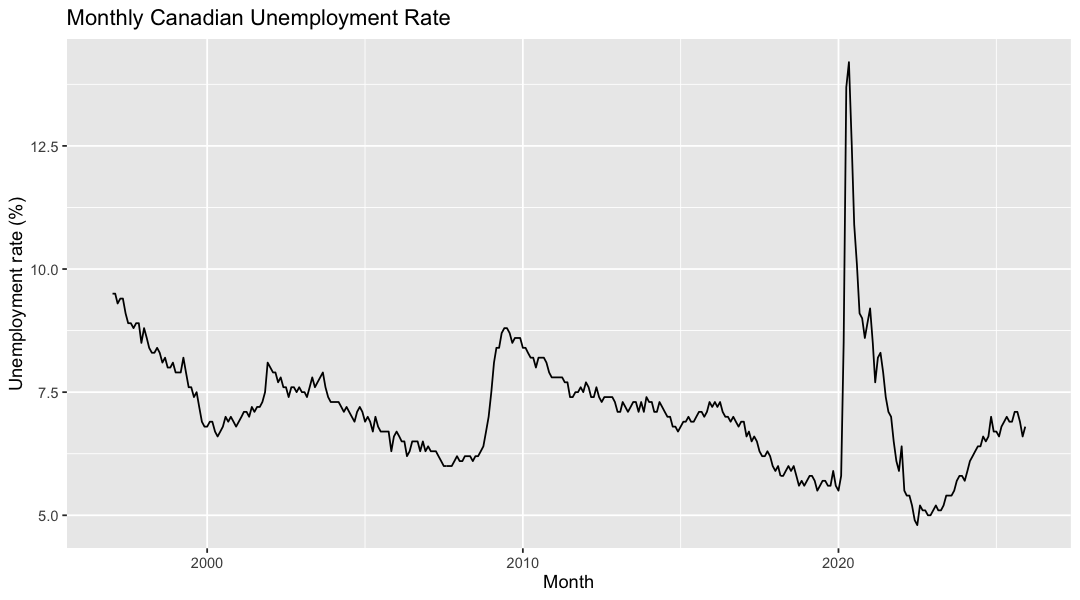

In [29]:
options(repr.plot.width = 9, repr.plot.height = 5)
unemp_plot <- ggplot(eda_data, aes(x = month, y = unemployment_rate)) + 
    geom_line() +
    labs(
    title = "Monthly Canadian Unemployment Rate",
    x = "Month",
    y = "Unemployment rate (%)")
unemp_plot

### Total employment

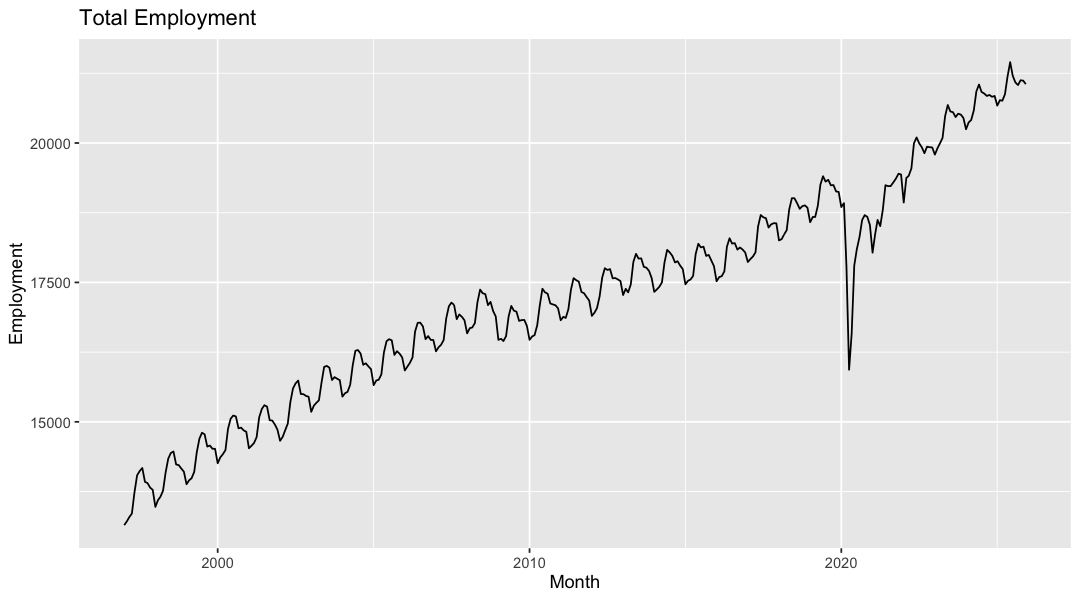

In [30]:
options(repr.plot.width = 9, repr.plot.height = 5)
tot_emp_plot <- ggplot(eda_data, aes(x = month, y = total_employment)) + 
    geom_line() +
    labs(
    title = "Total Employment",
    x = "Month",
    y = "Employment")
tot_emp_plot

### All-industry GDP

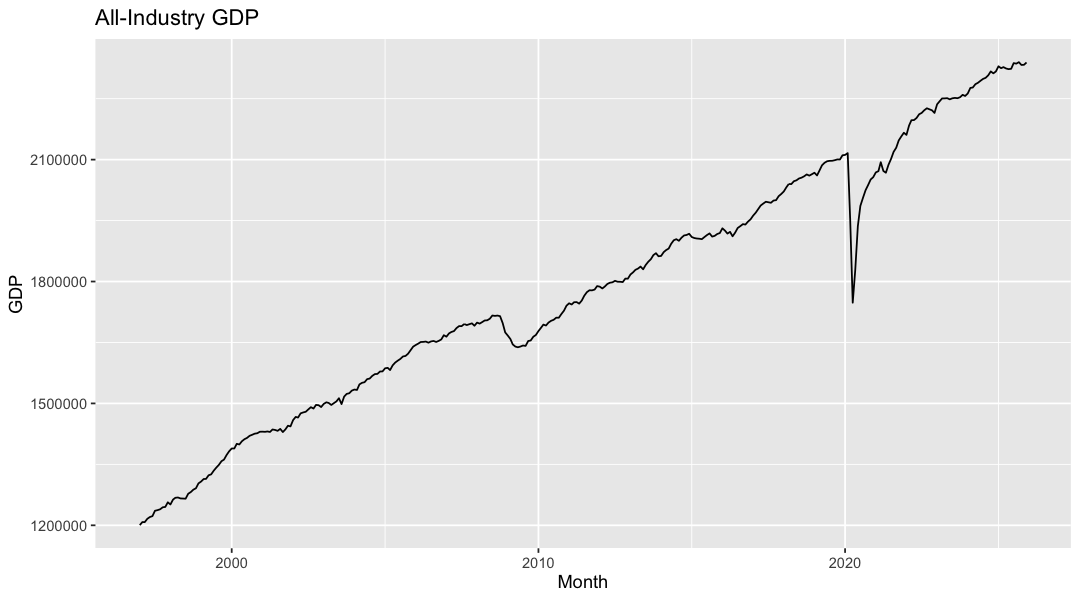

In [31]:
options(repr.plot.width = 9, repr.plot.height = 5)
all_gdp_plot <- ggplot(eda_data, aes(x = month, y = all_gdp)) + 
    geom_line() +
    labs(
    title = "All-Industry GDP",
    x = "Month",
    y = "GDP")
all_gdp_plot

In [33]:
#Create time series object
unemp_ts <- ts(eda_data$unemployment_rate, start = c(1997, 1), frequency = 12)

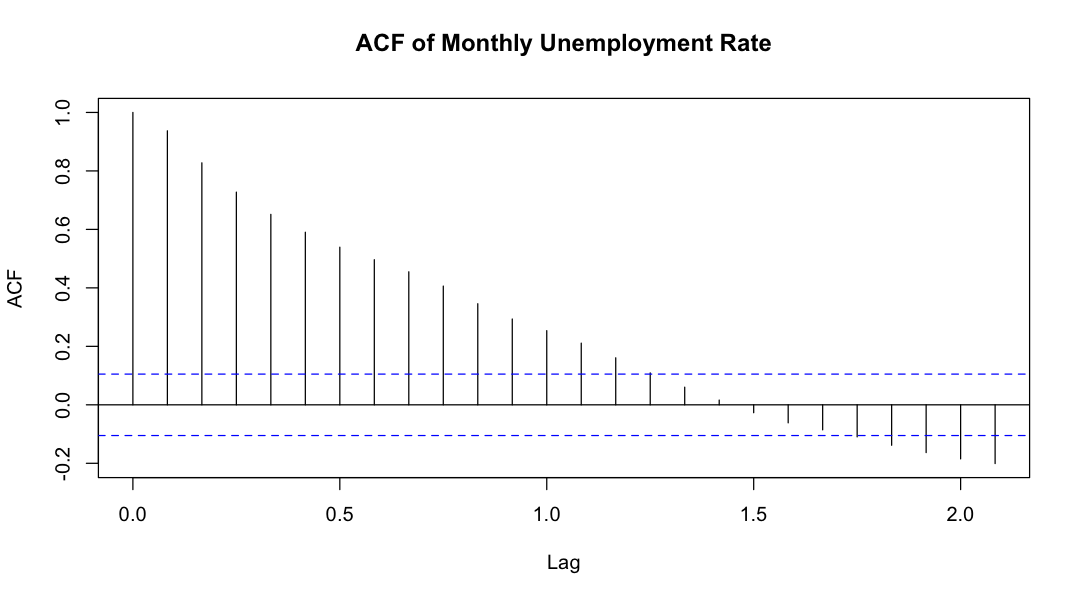

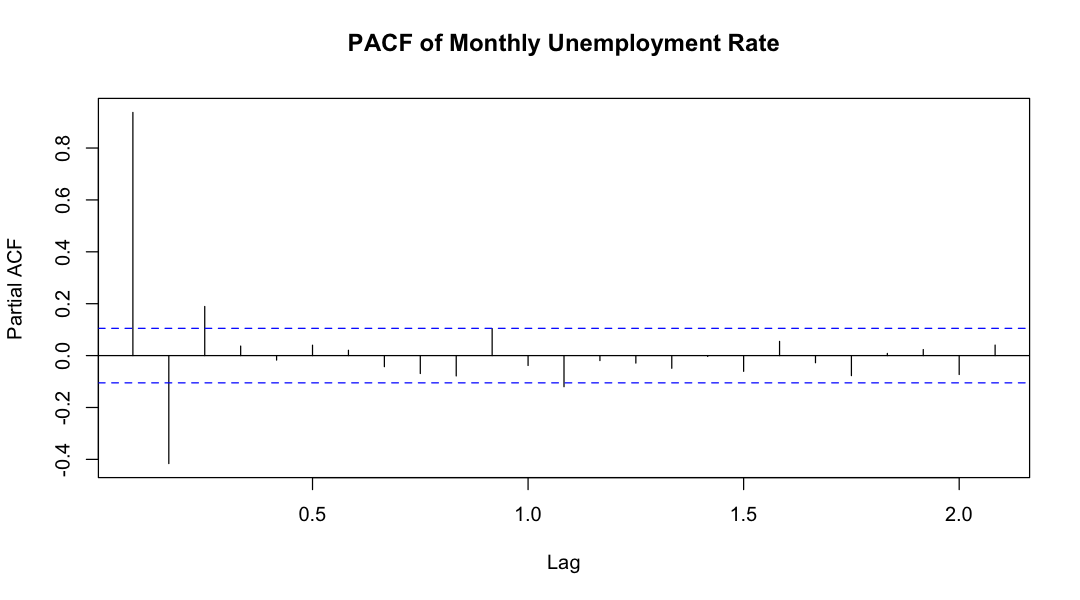

In [34]:
#ACF/PACF of the unemployment ts object
acf(unemp_ts, main = "ACF of Monthly Unemployment Rate")
pacf(unemp_ts, main = "PACF of Monthly Unemployment Rate")

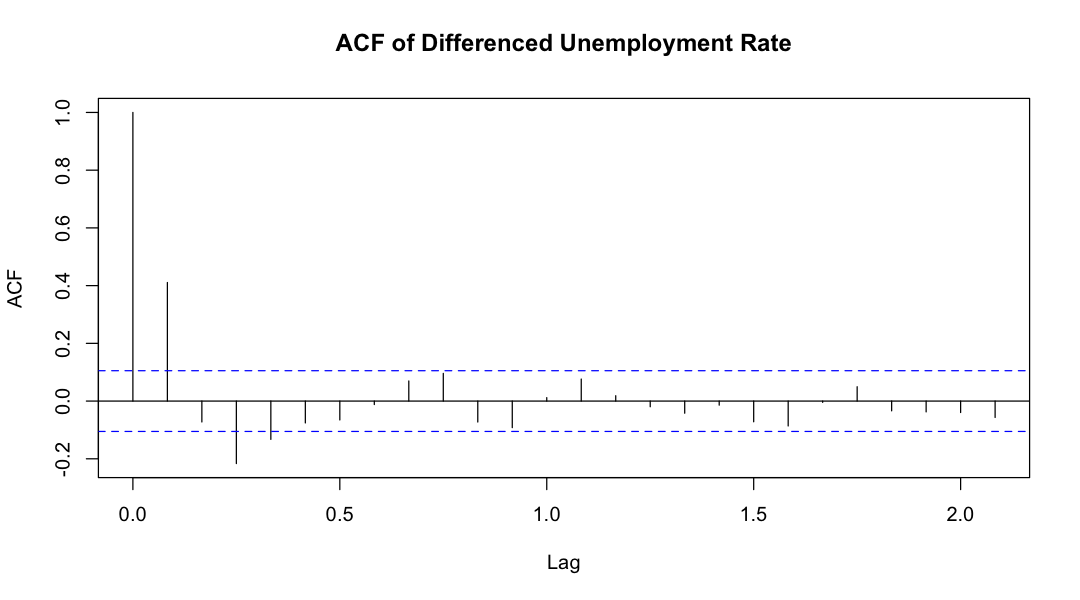

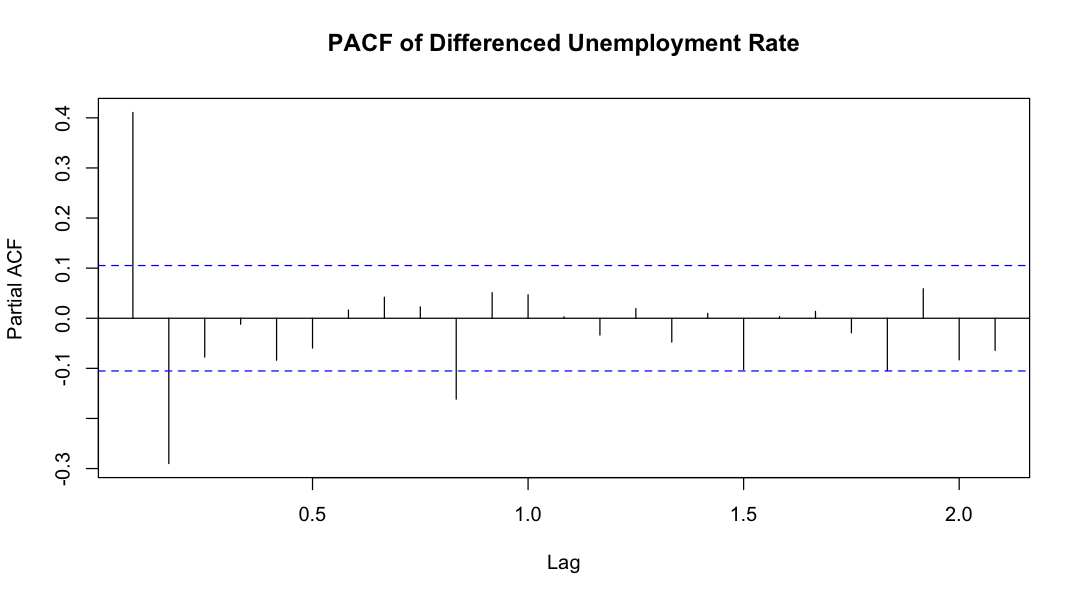

In [35]:
#ACF/PACF of the differenced unemployment ts object
acf(diff(unemp_ts), main = "ACF of Differenced Unemployment Rate")
pacf(diff(unemp_ts), main = "PACF of Differenced Unemployment Rate")

In [40]:
#Relationship investigation between variables?
library(corrplot)

corr_data <- eda_data %>%
  select(-month)

cor_matrix <- cor(corr_data)
print(cor_matrix)


The downloaded binary packages are in
	/var/folders/6n/clr3c9_d5fl3fbpcsrmvbd5m0000gn/T//RtmpwRaYk5/downloaded_packages
                  unemployment_rate total_employment    all_gdp
unemployment_rate         1.0000000       -0.4839627 -0.4686860
total_employment         -0.4839627        1.0000000  0.9869102
all_gdp                  -0.4686860        0.9869102  1.0000000


## Baselines